# Part IV: Sentiment analysis using LSTM [20 points]
In this part, we perform a sentiment analysis using LSTM model. The final (improved) model should achieve a test accuracy of greater than 75%.

In [1]:
# !pip install wordcloud nltk torchtext
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams
from collections import Counter
import numpy as np
import re
from nltk.tokenize import word_tokenize
import time
from sklearn.model_selection import train_test_split
import random

In [2]:
# !pip uninstall torch torchtext
!pip install torch==2.3.0 torchtext==0.18.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 935.7 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 57.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 89.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 75.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 1.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 30.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 13.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 8.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━

In [3]:
import torch
import torchtext
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator

/usr/local/lib/python3.10/dist-packages/torchtext/data/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.10/dist-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.10/dist-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated

## Step 1: Data exploration and preprocessing

1. Load your chosen dataset and print the main statistics

In [4]:
# from google.colab import drive
# drive.mount('/content/drive')
# %cd ..
# %cd /content/drive/MyDrive



In [5]:
seed = 42
torch.manual_seed(seed)
# torch.cuda.manual_seed(seed)
random.seed(seed)
# np.random.seed(seed)

print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

True


In [6]:
### ADD YOUR CODE HERE ###
#mean,median and mode
#From CSE574 ra65_a0 assignment, reusing the code to get stastics

df = pd.read_csv("/kaggle/input/twitter-airline-sentiment/Tweets.csv")


mean_values = df.mean(numeric_only=True)
print("The mean values:",mean_values,sep='\n')
print('\n')

median_values = df.median(numeric_only=True)
print("The median values:",median_values,sep='\n')
print('\n')

mode_values = df.mode(numeric_only=True)
print("The mode values:",mode_values,sep='\n')
print('\n')

standard_deviation = df.std(numeric_only=True)
print("The standard deviation values:",standard_deviation,sep='\n')
print('\n')

variance_values = df.var(numeric_only=True)
print("The variance values:",variance_values,sep='\n')
print('\n')

min_values = df.min(numeric_only=True)
print("The min values:",min_values,sep='\n')
print('\n')

max_values = df.max(numeric_only=True)
print("The max values:",max_values,sep='\n')
print('\n')


The mean values:
tweet_id                        5.692184e+17
airline_sentiment_confidence    9.001689e-01
negativereason_confidence       6.382983e-01
retweet_count                   8.265027e-02
dtype: float64


The median values:
tweet_id                        5.694779e+17
airline_sentiment_confidence    1.000000e+00
negativereason_confidence       6.706000e-01
retweet_count                   0.000000e+00
dtype: float64


The mode values:
               tweet_id  airline_sentiment_confidence  \
0    569600137296633856                           1.0   
1    569601363799359488                           NaN   
2    569621879633391616                           NaN   
3    569622568459636736                           NaN   
4    569680231012773888                           NaN   
..                  ...                           ...   
150  570307434113310720                           NaN   
151  570307948171423745                           NaN   
152  570307949614256128                 

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


2. Print the first 5 rows of the dataset to understand its structure

In [7]:
### ADD YOUR CODE HERE ###
df.head()

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


3. Provide a brief description of the dataset

<span style='color:#528aae'>Dataset Description</span>

The dataset is a collection of tweets from travellers who have used different airlines an their opinions about the experience. The tweets has information such as airline services and the data includes the different sentiments categorized as postive, negative and netural. Each tweet is connected to different airlines along with user's name and time created and the location.

(Source: https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment/data)

4. Display descriptive statistics

In [8]:
### ADD YOUR CODE HERE ###

#samples
samples = df.shape[0]

# three sentiment categories mentioned above
class_distribution = df['airline_sentiment'].value_counts(normalize=True) * 100

#average review length
df['review_length'] = df['text'].apply(lambda x: len(x.split()))
average_review_length = df['review_length'].mean()

vector = CountVectorizer(stop_words='english')
X = vector.fit_transform(df['text'])
vocab_size = len(vector.get_feature_names_out())

# Print statistics
print(f"Number of samples: {samples}\n")
print("Class distribution (%):\n")
print(class_distribution)
print(f"\nAverage review length: {average_review_length} words\n")
print(f"Vocabulary size: {vocab_size}")


Number of samples: 14640

Class distribution (%):

airline_sentiment
negative    62.691257
neutral     21.168033
positive    16.140710
Name: proportion, dtype: float64

Average review length: 17.65341530054645 words

Vocabulary size: 14770


5. Handle missing values

In [9]:
df.count()

tweet_id                        14640
airline_sentiment               14640
airline_sentiment_confidence    14640
negativereason                   9178
negativereason_confidence       10522
airline                         14640
airline_sentiment_gold             40
name                            14640
negativereason_gold                32
retweet_count                   14640
text                            14640
tweet_coord                      1019
tweet_created                   14640
tweet_location                   9907
user_timezone                    9820
review_length                   14640
dtype: int64

In [10]:
### ADD YOUR CODE HERE ###

df.drop_duplicates(inplace=True)

#checking for missing values
missing_values = df.isnull().sum()

print("Missing values in each column:\n")
print(missing_values)

# removing the columns airline airline_sentiment_gold, negativereason_gold, tweet_coord since lot of the columns are empty.
clean_df = df.drop(['airline_sentiment_gold','negativereason_gold','tweet_coord'],axis=1)

clean_df['negativereason'].fillna('Unknown', inplace=True)
clean_df['negativereason_confidence'].fillna(clean_df['negativereason_confidence'].mean(), inplace=True)

clean_df = clean_df.dropna(subset=['user_timezone'])

clean_df['tweet_location'].fillna('Unknown', inplace=True)

#checking for missing values
missing_values = clean_df.isnull().sum()

print("Missing values in each column:\n")
print(missing_values)


Missing values in each column:

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5445
negativereason_confidence        4101
airline                             0
airline_sentiment_gold          14564
name                                0
negativereason_gold             14572
retweet_count                       0
text                                0
tweet_coord                     13589
tweet_created                       0
tweet_location                   4723
user_timezone                    4814
review_length                       0
dtype: int64
Missing values in each column:

tweet_id                        0
airline_sentiment               0
airline_sentiment_confidence    0
negativereason                  0
negativereason_confidence       0
airline                         0
name                            0
retweet_count                   0
text                            0
tweet_cre

<ipython-input-10-84178ea08e83>:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clean_df['negativereason'].fillna('Unknown', inplace=True)
<ipython-input-10-84178ea08e83>:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [11]:
clean_df.shape[0]

9790

In [12]:
#some more cleaning of text
def clean_text(string_value):

  text = string_value
  text = re.sub(r'\.{2,}', ' ', string_value)
  text = re.sub(r'\s{2,}',' ', text)

  #removing the trailing space
  text = text.strip()

  return text

clean_df['text'] = clean_df['text'].apply(clean_text)

<span style='color:green'>### YOUR ANSWER ###</span>

For the missing data we removed the columns airline_sentiment_gold, negativereason_gold, tweet_coord since most of the values for columns were empty. It did not make sense to use it since the majority data be filled with artifical data will not benifit learning of new information. Wheras for the columns user_timezone we drop the samples for those which have missing values, and for tweet_location we replace with unknown. Last for the negativereason and negativereason_confidence as they seemed like attributes that can help understand the sentiments in combined with the airline_sentiment attribute, so we decide to fill the missing values with unknown and the mean for the confidence value.

Further added some text cleaning of the reviews.

6. Create visualizations to gain insights into the data

Visualization 1: Histogram for Words and Chars Review Lengths

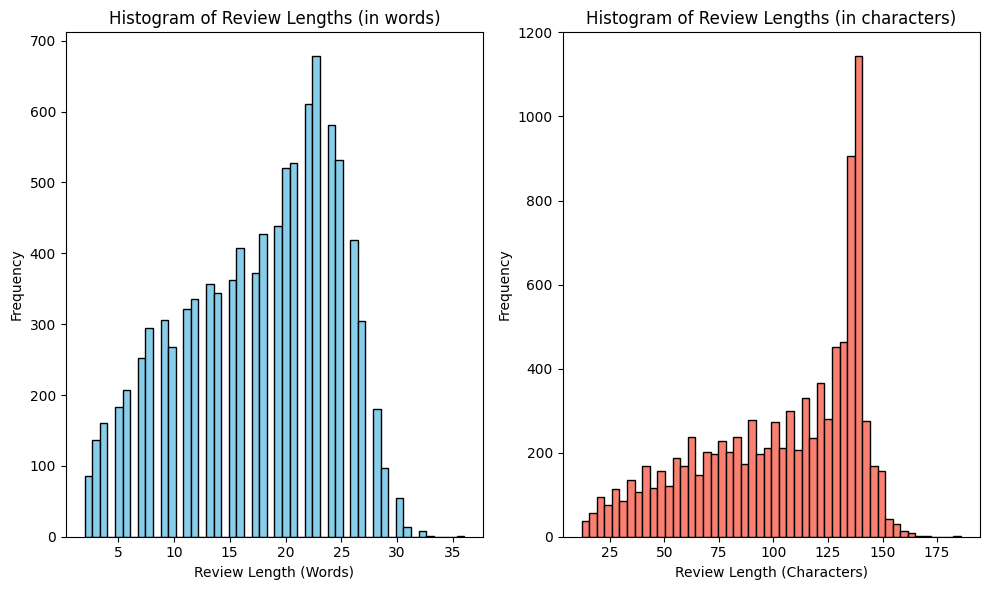

In [13]:
### ADD YOUR CODE HERE ###

words = clean_df['text'].apply(lambda x: len(x.split()))
chars = clean_df['text'].apply(lambda x: len(x))

fig, ax = plt.subplots(1, 2, figsize=(10, 6))

# Histogram of review lengths (words)
ax[0].hist(words, bins=50, color='skyblue', edgecolor='black')
ax[0].set_title('Histogram of Review Lengths (in words)')
ax[0].set_xlabel('Review Length (Words)')
ax[0].set_ylabel('Frequency')

# Histogram of review lengths (characters)
ax[1].hist(chars, bins=50, color='salmon', edgecolor='black')
ax[1].set_title('Histogram of Review Lengths (in characters)')
ax[1].set_xlabel('Review Length (Characters)')
ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


Visualization 2: Word Clouds for Each Sentiment Category

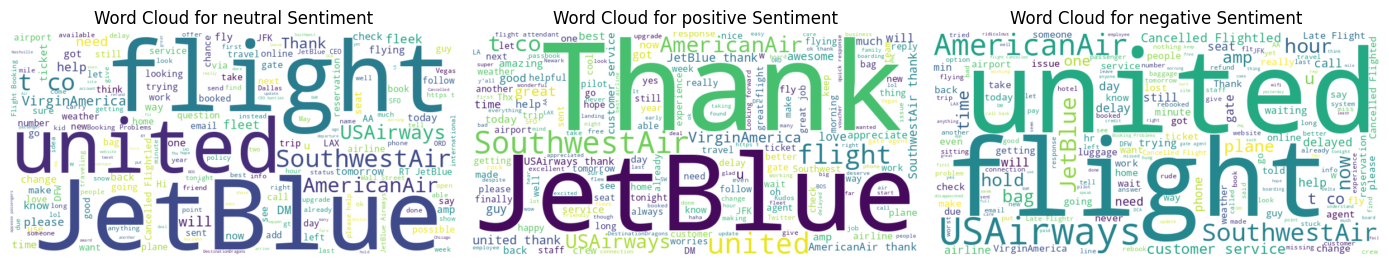

In [14]:
# Generate a word cloud for each sentiment class
sentiment_category = clean_df['airline_sentiment'].unique()

fig, ax = plt.subplots(1, 3, figsize=(14, 6))

for i, sentiment in enumerate(sentiment_category):
    sentiments = clean_df[clean_df['airline_sentiment'] == sentiment]
    text = ' '.join(sentiments['text'])

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    ax[i].imshow(wordcloud, interpolation='bilinear')
    ax[i].set_title(f"Word Cloud for {sentiment} Sentiment")
    ax[i].axis('off')


plt.tight_layout()
plt.show()


Visualization 3: N-Gram Frequency Distribution

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


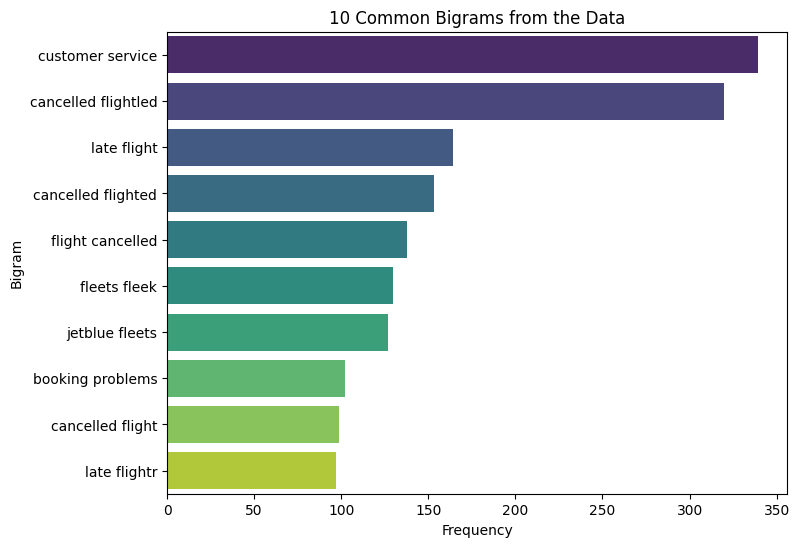

In [38]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
  text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
  return text

clean_df['processed_text'] = clean_df['text'].apply(preprocess_text)

n = 2
bigrams_vals = []
for text in clean_df['processed_text']:
    tokens = text.split()
    filtered_tokens = [word for word in tokens if word not in stop_words]
    bigrams = ngrams(filtered_tokens, n)
    bigrams_vals.extend(bigrams)

bigram_freq = Counter(bigrams_vals)

common_bigrams = bigram_freq.most_common(10)

labels = [' '.join(bigram) for bigram, _ in common_bigrams]
counts = [count for _, count in common_bigrams]

# Plot the top 10 most common bigrams
plt.figure(figsize=(8, 6))
sns.barplot(x=counts, y=labels, palette='viridis')
plt.title('10 Common Bigrams from the Data')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.show()


7. Data preparation

Tokenization

In [16]:
### ADD YOUR CODE HERE ###
#tokenizing the data

nltk.download('punkt_tab')

tokenizer = word_tokenize
torchtext_tokenizer = get_tokenizer("basic_english")

def tokenizeText_func(text, tokenizer_type="nltk"):
    if tokenizer_type == "nltk":
      return [tokenizer(txt) for txt in text]
    elif tokenizer_type == "torchtext":
      return [torchtext_tokenizer(txt) for txt in text]

#NLTK tokenization
start_time = time.time()
nltk_tokenized_data = tokenizeText_func(clean_df['text'], tokenizer_type="nltk")
nltk_time = time.time() - start_time

#TorchText tokenization
start_time = time.time()
torchtext_tokenized_data = tokenizeText_func(clean_df['text'], tokenizer_type="torchtext")
torchtext_time = time.time() - start_time

print(f"NLTK Tokenization Time for all Reviews: {nltk_time:.5f} seconds")
print(f"TorchText Tokenization Time for all Reviews: {torchtext_time:.5f} seconds")


print("\nSample of NLTK Tokenized Data:", nltk_tokenized_data[:2])
print("Sample of TorchText Tokenized Data:", torchtext_tokenized_data[:2])


[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
NLTK Tokenization Time for all Reviews: 1.84487 seconds
TorchText Tokenization Time for all Reviews: 0.14206 seconds

Sample of NLTK Tokenized Data: [['@', 'VirginAmerica', 'What', '@', 'dhepburn', 'said', '.'], ['@', 'VirginAmerica', 'plus', 'you', "'ve", 'added', 'commercials', 'to', 'the', 'experience', 'tacky', '.']]
Sample of TorchText Tokenized Data: [['@virginamerica', 'what', '@dhepburn', 'said', '.'], ['@virginamerica', 'plus', 'you', "'", 've', 'added', 'commercials', 'to', 'the', 'experience', 'tacky', '.']]


From above processing we can see that the tokenization method using NLTK took more time than torchtext. And also we can see that torchext reads the user names with the '@' sign as they are part of the user being tagged, whereas it is separted as a token using NLTK. Even though we can that NLTK method creates more characters we can see in this case the second sample the character count is equal but the splits are differently done.

So it depends what critieria is important time or proper control over the split of the charaters. If time is important then torchtext is preferred otherwise we can choose NLTK.

For our case we decided to go ahead with torchtext tokenization aslo since it properly considers the '@' sign with the user name.

Building vocab

In [17]:
#Build vocabulary from tokenized data
vocab = build_vocab_from_iterator(torchtext_tokenized_data , specials=["<unk>", "<pad>"])

print("Vocabulary Size:", len(vocab))
tokens = [vocab.get_itos()[i] for i in range(min(10, len(vocab)))]
print("First 10 tokens in the vocabulary:", tokens)


Vocabulary Size: 13387
First 10 tokens in the vocabulary: ['<unk>', '<pad>', '.', 'to', 'i', 'the', "'", '!', '?', 'a']


In [18]:
#sequence of numerical indices
def text_sequence(text, vocab):
    tokens = torchtext_tokenizer(text)
    return [vocab[token] for token in tokens]

numerical_sequences = [text_sequence(text, vocab) for text in clean_df['text']]

# print("Numerical Sequence:", numerical_sequences)


Used pad_sequence function of rnn library.

In [19]:
from torch.nn.utils.rnn import pad_sequence

# Convert sequences to tensors
tensor_sequences = [torch.tensor(seq) for seq in numerical_sequences]

# Pad sequences in batch
padded_sequences_tensor = pad_sequence(tensor_sequences, batch_first=True, padding_value=vocab["<pad>"])

print("Padded Sequences:", padded_sequences_tensor)

Padded Sequences: tensor([[  83,   57, 7520,  ...,    1,    1,    1],
        [  83,  528,   10,  ...,    1,    1,    1],
        [  83,    4,  250,  ...,    1,    1,    1],
        ...,
        [  19,   17,   13,  ...,    1,    1,    1],
        [  19,  197,   15,  ...,    1,    1,    1],
        [  19,   10,   33,  ...,    1,    1,    1]])


The main impact of padding is that makes sure the sequences are the same length so that when send through the neural networks it helps since different length sequences will not work well with batch processing in the neural network. Similarly if the length is more then truncation cuts off  the longer sequence which could remove some important information that is why choosing max_length is important. Since we are using torch's rnn function of pad_squence it takes care to pad based on the longest sequence length.

8. Split dataset into train, validation, and test sets

In [20]:
### ADD YOUR CODE HERE ###

from torch.utils.data import Dataset, DataLoader, TensorDataset
from imblearn.over_sampling import SMOTE

X = padded_sequences_tensor      #clean_df['text']
y = clean_df['airline_sentiment']

#encoding the sentiments
y = y.map({'negative': 0, 'neutral': 1, 'positive': 2}).values

# print(X)
# print(y)

X_train, X_rest, y_train, y_rest = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=0.5, random_state=42, stratify=y_rest)

X_train_np = X_train.numpy()
# y_train_np = y_train.numpy()

#handle class imbalance
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_np, y_train)

# smote data back to tensors
X_train_tensor = torch.tensor(X_train_smote, dtype=torch.long)
y_train_tensor = torch.tensor(y_train_smote, dtype=torch.long)

# Convert validation and test labels to tensors
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

#training, validation, and testing
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val, y_val_tensor)
test_dataset = TensorDataset(X_test, y_test_tensor)

#size of each set
print(f"Training set size after SMOTE: {len(X_train_tensor)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")

batch_size = 32

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)



Training set size after SMOTE: 12588
Validation set size: 1468
Test set size: 1469


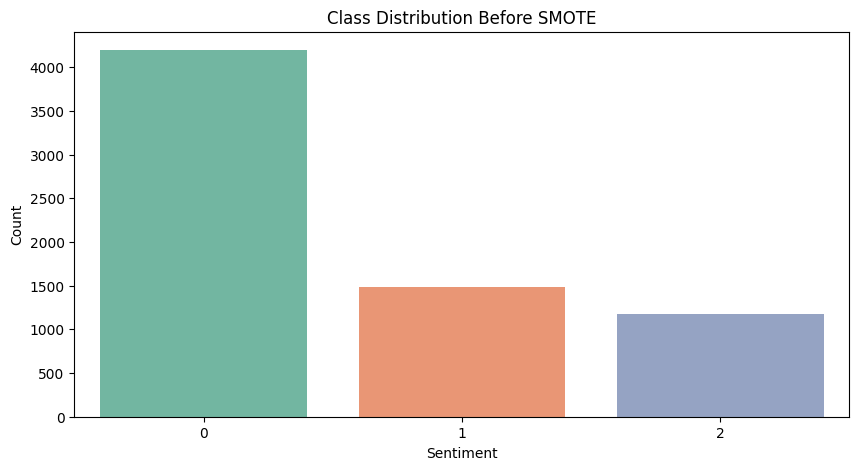

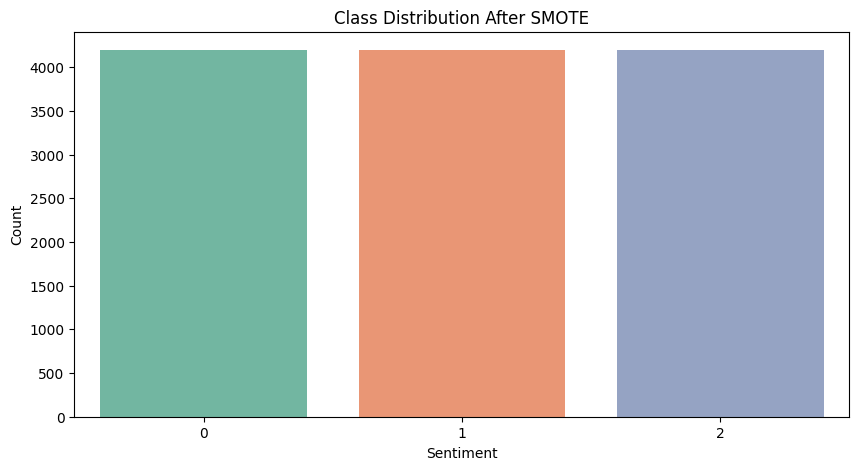

In [21]:
# Plot the class distribution before SMOTE
plt.figure(figsize=(10, 5))
sns.countplot(x=y_train, palette='Set2')
plt.title('Class Distribution Before SMOTE')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

# Plot the class distribution after SMOTE
plt.figure(figsize=(10, 5))
sns.countplot(x=y_train_smote, palette='Set2')
plt.title('Class Distribution After SMOTE')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


## Step 2: Baseline LSTM Model

1. Build an LSTM model

In [22]:
### ADD YOUR CODE HERE ###
!pip install torchinfo
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary

class LSTM_Model(nn.Module):
  def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, dropout):
    super(LSTM_Model, self).__init__()

    #embedded layer
    self.embedding = nn.Embedding(vocab_size, embedding_dim)

    # LSTM layers
    self.lstm1 = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, dropout=dropout,num_layers=3)
    self.lstm2 = nn.LSTM(hidden_dim, hidden_dim, batch_first=True, dropout=dropout)
    self.lstm3 = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)


    self.dropout = nn.Dropout(dropout)

    # Fully connected layer
    self.fc = nn.Linear(hidden_dim, output_dim)


  def forward(self,x):

    # Embedding layer
    x = self.embedding(x)

    #LSTM layers
    x, (hn, cn) = self.lstm1(x)
    x, (hn, cn) = self.lstm2(x)
    x, (hn, cn) = self.lstm3(x)

    x = x[:, -1, :]

    x = self.dropout(x)

    x = self.fc(x)

    return F.softmax(x, dim=1)



vocab_size = len(vocab)
embedding_dim = 100
hidden_dim = 64  
output_dim = 3  #negative, neutral, positive
dropout = 0.4



In [23]:
model = LSTM_Model(vocab_size, embedding_dim, hidden_dim, output_dim, dropout)
model.to(device)
summary(model)

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/rnn.py:83: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.4 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


Layer (type:depth-idx)                   Param #
LSTM_Model                               --
├─Embedding: 1-1                         1,338,700
├─LSTM: 1-2                              109,056
├─LSTM: 1-3                              33,280
├─LSTM: 1-4                              33,280
├─Dropout: 1-5                           --
├─Linear: 1-6                            195
Total params: 1,514,511
Trainable params: 1,514,511
Non-trainable params: 0

In [24]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(device)
# model.to(device)

2. Train your model

In [25]:
### ADD YOUR CODE HERE ###
import torch.optim as optim
from sklearn.metrics import accuracy_score

loss_function_lstm = nn.CrossEntropyLoss()
optimizer_lstm = optim.Adam(model.parameters(), lr=0.001)


# used code from a1_part1_ra65_hsingh47

epochs = 30

best_validation_loss_lstm = float('inf')
best_epoch_lstm = 0
train_loss_lstm = []
validation_loss_lstm = []
train_accuracy_lstm = []
validation_accuracy_lstm = []
best_model_weight_lstm = None

for epoch in range(epochs):
  model.train()

  start_time = time.time()

  loop_train_loss_lstm = 0
  correct_train_length_lstm = 0
  total_train_lstm = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_lstm.zero_grad()

    outputs = model(inputs)

    loss = loss_function_lstm(outputs, labels)
    loss.backward()
    optimizer_lstm.step()

    _, predicted_lstm = torch.max(outputs, 1)
    total_train_lstm += labels.size(0)
    correct_train_length_lstm += (predicted_lstm == labels).sum().item()

    loop_train_loss_lstm += loss.item()


  #training accuracy and loss
  train_accuracy_value_lstm = 100 * correct_train_length_lstm / total_train_lstm
  train_loss_lstm.append(loop_train_loss_lstm / len(train_loader))
  train_accuracy_lstm.append(train_accuracy_value_lstm)

  #Validation
  model.eval()
  loop_val_loss_lstm = 0
  correct_val_lstm = 0
  total_val_lstm = 0

  with torch.no_grad():
    for val_inputs, val_labels in val_loader:
      val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
      val_outputs = model(val_inputs)

      val_labels = val_labels.view(-1)
      val_loss = loss_function_lstm(val_outputs, val_labels)

      # Track validation accuracy
      _, predicted_lstm = torch.max(val_outputs, 1)

      total_val_lstm += val_labels.size(0)
      correct_val_lstm += (predicted_lstm == val_labels).sum().item()

      loop_val_loss_lstm += val_loss.item()

  #validation accuracy and loss
  val_accuracy_lstm = 100 * correct_val_lstm / total_val_lstm
  validation_loss_lstm.append(loop_val_loss_lstm / len(val_loader))
  validation_accuracy_lstm.append(val_accuracy_lstm)

  print(f"Epoch [{epoch+1}/{epochs}], "
    f"Train Loss: {train_loss_lstm[-1]:.4f}, Train Accuracy: {train_accuracy_lstm[-1]:.2f}%, "
    f"Val Loss: {validation_loss_lstm[-1]:.4f}, Val Accuracy: {validation_accuracy_lstm[-1]:.2f}%")

  end_time = time.time()
  training_time_lstm = end_time - start_time
  print(f"Training Time: {training_time_lstm:.2f} seconds")

  # Save model weights with best validation accuracy
  if loop_val_loss_lstm < best_validation_loss_lstm:
    best_validation_loss_lstm = loop_val_loss_lstm
    best_epoch_lstm = epoch + 1
    best_model_weight_lstm = model.state_dict()



Epoch [1/30], Train Loss: 1.0393, Train Accuracy: 43.63%, Val Loss: 0.9101, Val Accuracy: 61.10%
Training Time: 1.92 seconds
Epoch [2/30], Train Loss: 0.9716, Train Accuracy: 51.93%, Val Loss: 1.0077, Val Accuracy: 48.23%
Training Time: 1.64 seconds
Epoch [3/30], Train Loss: 0.9585, Train Accuracy: 53.69%, Val Loss: 0.9045, Val Accuracy: 60.97%
Training Time: 1.64 seconds
Epoch [4/30], Train Loss: 0.9359, Train Accuracy: 56.48%, Val Loss: 0.9345, Val Accuracy: 57.56%
Training Time: 1.66 seconds
Epoch [5/30], Train Loss: 0.9306, Train Accuracy: 57.71%, Val Loss: 0.9253, Val Accuracy: 59.06%
Training Time: 1.76 seconds
Epoch [6/30], Train Loss: 0.9163, Train Accuracy: 59.58%, Val Loss: 0.9053, Val Accuracy: 61.92%
Training Time: 1.63 seconds
Epoch [7/30], Train Loss: 0.9061, Train Accuracy: 62.00%, Val Loss: 0.9073, Val Accuracy: 62.81%
Training Time: 1.68 seconds
Epoch [8/30], Train Loss: 0.9032, Train Accuracy: 63.04%, Val Loss: 0.8867, Val Accuracy: 65.53%
Training Time: 1.70 seconds


**Setups Tested:**

The different setups tried are using manaul tuning by changing and using trial and error with batch size, hidden dimention, learning rate value adjustments and dropout values. Some of the setups are:

We started with a big number to see the effect and it did not performance well at all.

- batch size 256, hidden_dim 1024, dropout=0.8, learnign rate 0.0001
- batch 32, idden_dim 128, dropout=0.8, learnign rate 0.0001 **(68.21%)**
- batch 32, idden_dim 128, dropout=0.4, learnign rate 0.0001 (66.10%)
- batch 64, hidden_dim 128, dropout=0.4, learnign rate 0.0001 **(69.78%)**
- batch 64, hidden_dim 128, dropout=0.4, learnign rate 0.001 **(68.89%)**
- batch 64, hidden_dim 128, dropout=0.4, learnign rate 0.01 (56.98%)
- batch 64, hidden_dim 64,  dropout=0.4, learnign rate 0.01 (60.99%)
- batch 64, hidden_dim 64,  dropout=0.4, learnign rate 0.0001 (66.58%)
- batch 64, hidden_dim 64,  dropout=0.4, learnign rate 0.001 **(68.82%)**
- batch 32, hidden_dim 64,  dropout=0.4, learnign rate 0.001 **(69.71%)**
- batch 32, hidden_dim 64,  dropout=0.4, learnign rate 0.0001 (67.26%)
- batch 32, hidden_dim 64,  dropout=0.8, learnign rate 0.0001 **(68.55%)**
- batch 64, hidden_dim 128,  dropout=0.8, learnign rate 0.0001 **(69.03%)**
- batch 64, hidden_dim 128,  dropout=0.6, learnign rate 0.0001 (67.67%)
- batch 64, hidden_dim 128,  dropout=0.5, learnign rate 0.0001 **(68.14%)**
- batch 32, hidden_dim 256,  dropout=0.4, learnign rate 0.0001 **(68.07%)**

During a different trial and error we found out that the batch size of 64 and 32 were good values for this dataset training. When combined with hidden units of 128 we can a see test accuracy between the range of percentages 68% -69% with one or two reaching 70%. And the learning that showed some good values is 0.0001. Lastly the dropout value of 0.4 was a good value for this data, even though we can see how 0.8 value did give a few good test accuracies.

Another common aspects during this training was that the training metrics were good, however there were big fluctuations with the validation metrics and we see some of it in the graphs below.


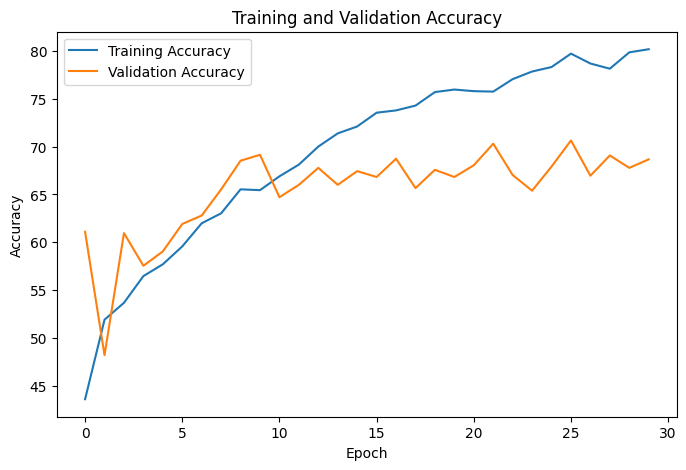

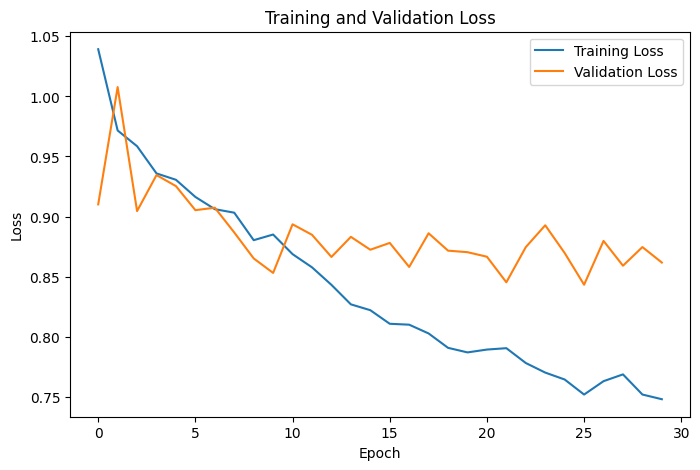

In [26]:
#Training,Validation and Test Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy_lstm, label='Training Accuracy')
plt.plot(validation_accuracy_lstm, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Training,Validation and Test Loss graph
plt.figure(figsize=(8, 5))
plt.plot(train_loss_lstm, label='Training Loss')
plt.plot(validation_loss_lstm, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

<span style='color:green'>### YOUR ANSWER ###</span>

Analysis of the graphs:

**Accuracy Graph:**

As we see in the first graph plots the training and validation accuracies. We can notice that the trianing accuracy is increasing steadily and model seems to be learning.The trianing accuracy value reaches 80% almost. Whereas there is some fluctuations with the validation accruacy. But we can see the fluctations are still between 65% - 70%  and stablizing around those values. Now this gap between the metrics can show that the model might be memorzing a little. This could makes sense since a lot of the data in the other classes had to be handled using Smote so the chances of slight overfitting can be seen.

**Loss Graph:**

Similarly here for the loss graph the training loss are higher than the validation loss. The trianing model does show learning happening but again some memorizing happening that causes the fluctuations. 

Now some of the reasosn for these flucntuations could be how the LSTM architecture is setup and the different hyperparamters used. Now our model has three layers of LSTM which is usally good but in this case could be leading to some memorizing. Another apsect is the tunning now the dropout value usually helps the model train better but finding a right value is important. In our case 0.4 was a decent value as when tested with differnt setups it gave accuaracy in the range of 65% and above. Here is the less batch size also helps with the training and validation accuracy we get. And the other two hyperparameters of learning rate and hidden units selected help maintain the values above 50%.

However to better increase the validation accruacy and prevent overfitting we  would need to apply some regularization techniques such as using L2 regulartization or even early stopping.



3. Evaluation and analysis

In [27]:
### ADD YOUR CODE HERE ###
from sklearn.metrics import accuracy_score, precision_recall_fscore_support,confusion_matrix

#code referenced from a1_part1_ra65_hsingh47

# Test phase
model.eval()
correct_test_length_lstm = 0
total_test_lstm = 0
y_true_lstm = []
y_pred_lstm = []

# test_loss = []
test_accuracy_lstm =[]
test_total_loss_lstm = 0.0
predicted_list_lstm = []


with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model(inputs)

    labels = labels.view(-1)
    test_total_loss_lstm += loss_function_lstm(outputs, labels).item()

    _, predicted_lstm = torch.max(outputs, 1)
    predicted_test_probs = torch.softmax(outputs, dim=1)

    total_test_lstm += labels.size(0)
    correct_test_length_lstm += (predicted_lstm == labels).sum().item()

    y_true_lstm.extend(labels.cpu().numpy())
    y_pred_lstm.extend(predicted_lstm.cpu().numpy())
    predicted_list_lstm.extend(predicted_test_probs.cpu().numpy())


y_pred_lstm = np.array(y_pred_lstm)
y_true_lstm = np.array(y_true_lstm)
predicted_list_lstm = np.array(predicted_list_lstm)

test_accuracy_lstm = 100 * (correct_test_length_lstm / total_test_lstm)
print(f"Test Accuracy: {test_accuracy_lstm:.2f}%")

#precision, recall, F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_true_lstm, y_pred_lstm, average='weighted')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

test_loss_lstm = test_total_loss_lstm /len(test_loader)

test_accuracies_plot_lstm = [test_accuracy_lstm] * epochs
test_loss_plot_lstm = [test_loss_lstm] * epochs

Test Accuracy: 70.39%
Precision: 0.7130, Recall: 0.7039, F1: 0.7074


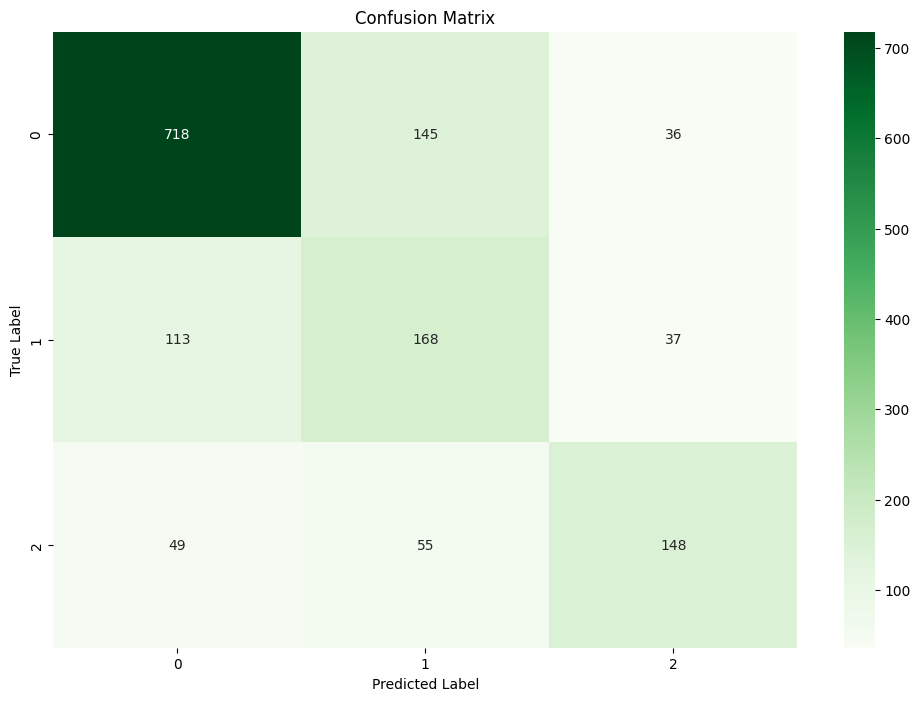

In [28]:
#Confusion Matrix
conf_matrix = confusion_matrix(y_true_lstm, y_pred_lstm)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

<span style='color:green'>### YOUR ANSWER ###</span>

The best base model setup so far with accuracy of 70.39% is the one with batch size 32, hidden dimension of 64, learning rate of 0.001, hidden size of 64, dropout value 0.4.  From our test data we can see that the model classifies around 70% of the data. And from the other metrics such as Precision of 0.7130 we can tell that 71.3% postive predictions were made. Now we see a balanced trade-off between the recall and precision with the F1-score shows that there is chance for improvement with model generalizing. 

As we see from the confusion matrix the one reason for lesser generalizing is becuase of the negative sentiment class being classified a lot more compared to netural and positve. And we know this also becuase we used SMOTE above to balance the data to help with model training. And in our dataset chosen the negative sentiment class has more data samples compared to the other two and we balanced that by adding more sample which do not exactly have the right representation of real data.

Other ways these few aspects that can be included to impove performace is using other regualrization methods or data augmentation. Since this is a sentiment analysis using LSTM  we could do augmention for the sentiments and certina other word embeddings. Some of the other methods for this is ones used in NLP like back translation, EDA for text or sentiment reviews, NLP alumentation or using the methods from the NLP library at the level of words, characters and sentence augmentation. (Source: https://neptune.ai/blog/data-augmentation-nlp) 


4. Save the weights of the trained neural network

In [29]:
### ADD YOUR CODE HERE ###
if best_model_weight_lstm is not None:
  torch.save(best_model_weight_lstm, 'lstm_base_model.pt')


## Step 3: Improved LSTM Model

1. Improve your baseline LSTM model

In [48]:
### ADD YOUR CODE HERE ###
from torchtext.vocab import GloVe
from torchtext.vocab import Vectors

class Improved_LSTM_Model(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, dropout, pretrained_embeddings=None):
        super(Improved_LSTM_Model, self).__init__()
        
        self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)


        # #LSTM layers with bidirectional
        # self.lstm1 = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, dropout=dropout, bidirectional=True)
        # self.lstm2 = nn.LSTM(2 * hidden_dim, hidden_dim, batch_first=True, dropout=dropout, bidirectional=True)
        # self.lstm3 = nn.LSTM(2 * hidden_dim, hidden_dim, batch_first=True, bidirectional=True)

        #GRU layers with bidirectional
        self.gru1 = nn.GRU(embedding_dim, hidden_dim, batch_first=True, dropout=dropout, bidirectional=True)
        self.gru2 = nn.GRU(2 * hidden_dim, hidden_dim, batch_first=True, dropout=dropout, bidirectional=True)
        self.gru3 = nn.GRU(2 * hidden_dim, hidden_dim, batch_first=True, dropout=dropout, bidirectional=True)
        self.gru4 = nn.GRU(2 * hidden_dim, hidden_dim, batch_first=True, dropout=dropout, bidirectional=True)
        self.gru5 = nn.GRU(2 * hidden_dim, hidden_dim, batch_first=True, bidirectional=True)


    
        self.dropout = nn.Dropout(dropout)
          
        # mutiply with 2 as its bidirectional
        self.fc = nn.Linear(2 * hidden_dim, output_dim)
    
    def forward(self,x):
    
        # Embedding layer
        x = self.embedding(x)
    
        # #LSTM layers
        # x, (hn, cn) = self.lstm1(x)
        # x, (hn, cn) = self.lstm2(x)
        # x, (hn, cn) = self.lstm3(x)

        #GRU layers
        x, (hn, cn) = self.gru1(x)
        x, (hn, cn) = self.gru2(x)
        x, (hn, cn) = self.gru3(x)
        x, (hn, cn) = self.gru4(x)
        x, (hn, cn) = self.gru5(x)
        
        x = x[:, -1, :]
    
        x = self.dropout(x)
    
        x = self.fc(x)
    
        return F.softmax(x, dim=1)


vocab_size = len(vocab)
embedding_dim = 100
hidden_dim = 128
output_dim = 3 
dropout = 0.4

glove = GloVe(name='6B', dim=100) #Vectors(name="glove.6B.100d.txt", cache='./glove') 


2. Create a new class for your improved model

In [49]:
### ADD YOUR CODE HERE ###
# new class created above
model_improved = Improved_LSTM_Model(vocab_size, embedding_dim, hidden_dim, output_dim, dropout, pretrained_embeddings=glove.vectors)
model_improved.to(device)
# summary(model)

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/rnn.py:83: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.4 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


Improved_LSTM_Model(
  (embedding): Embedding(400000, 100)
  (gru1): GRU(100, 128, batch_first=True, dropout=0.4, bidirectional=True)
  (gru2): GRU(256, 128, batch_first=True, dropout=0.4, bidirectional=True)
  (gru3): GRU(256, 128, batch_first=True, dropout=0.4, bidirectional=True)
  (gru4): GRU(256, 128, batch_first=True, dropout=0.4, bidirectional=True)
  (gru5): GRU(256, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)

3. Follow the same training and evaluation procedures

In [50]:
### ADD YOUR CODE HERE ###

batch_size = 32

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

loss_function_lstm_improved = nn.CrossEntropyLoss()
optimizer_lstm_improved = optim.Adam(model_improved.parameters(), lr=0.0001)


# used training loop code from a1_part1_ra65_hsingh47

epochs = 30

best_validation_loss_lstm_improved = float('inf')
best_epoch_lstm_improved = 0
train_loss_lstm_improved = []
validation_loss_lstm_improved = []
train_accuracy_lstm_improved = []
validation_accuracy_lstm_improved = []
best_model_weight_lstm_improved = None

for epoch in range(epochs):
  model_improved.train()

  start_time = time.time()

  loop_train_loss_lstm_improved = 0
  correct_train_length_lstm_improved = 0
  total_train_lstm_improved = 0

  for inputs, labels in train_loader:

    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_lstm_improved.zero_grad()

    outputs = model_improved(inputs)

    loss = loss_function_lstm_improved(outputs, labels)
    loss.backward()
    optimizer_lstm_improved.step()

    _, predicted_lstm_improved = torch.max(outputs, 1)
    total_train_lstm_improved += labels.size(0)
    correct_train_length_lstm_improved += (predicted_lstm_improved == labels).sum().item()

    loop_train_loss_lstm_improved += loss.item()


  #training accuracy and loss
  train_accuracy_value_lstm_improved = 100 * correct_train_length_lstm_improved / total_train_lstm_improved
  train_loss_lstm_improved.append(loop_train_loss_lstm_improved / len(train_loader))
  train_accuracy_lstm_improved.append(train_accuracy_value_lstm_improved)

  #Validation
  model_improved.eval()
  loop_val_loss_lstm_improved = 0
  correct_val_lstm_improved = 0
  total_val_lstm_improved = 0

  with torch.no_grad():
    for val_inputs, val_labels in val_loader:
      val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
      val_outputs = model_improved(val_inputs)

      val_labels = val_labels.view(-1)
      val_loss = loss_function_lstm_improved(val_outputs, val_labels)

      # Track validation accuracy
      _, predicted_lstm_improved = torch.max(val_outputs, 1)

      total_val_lstm_improved += val_labels.size(0)
      correct_val_lstm_improved += (predicted_lstm_improved == val_labels).sum().item()

      loop_val_loss_lstm_improved += val_loss.item()

  #validation accuracy and loss
  val_accuracy_lstm_improved = 100 * correct_val_lstm_improved / total_val_lstm_improved
  validation_loss_lstm_improved.append(loop_val_loss_lstm_improved / len(val_loader))
  validation_accuracy_lstm_improved.append(val_accuracy_lstm_improved)

  print(f"Epoch [{epoch+1}/{epochs}], "
    f"Train Loss: {train_loss_lstm_improved[-1]:.4f}, Train Accuracy: {train_accuracy_lstm_improved[-1]:.2f}%, "
    f"Val Loss: {validation_loss_lstm_improved[-1]:.4f}, Val Accuracy: {validation_accuracy_lstm_improved[-1]:.2f}%")

  end_time = time.time()
  training_time_lstm_improved = end_time - start_time
  print(f"Training Time: {training_time_lstm_improved:.2f} seconds")

  # Save model weights with best validation accuracy
  if loop_val_loss_lstm_improved < best_validation_loss_lstm_improved:
    best_validation_loss_lstm_improved = loop_val_loss_lstm_improved
    best_epoch_lstm_improved = epoch + 1
    best_model_weight_lstm_improved = model_improved.state_dict()




Epoch [1/30], Train Loss: 1.0753, Train Accuracy: 39.44%, Val Loss: 1.0375, Val Accuracy: 47.48%
Training Time: 5.02 seconds
Epoch [2/30], Train Loss: 1.0376, Train Accuracy: 45.51%, Val Loss: 0.9903, Val Accuracy: 53.07%
Training Time: 4.97 seconds
Epoch [3/30], Train Loss: 0.9916, Train Accuracy: 51.06%, Val Loss: 1.0069, Val Accuracy: 50.27%
Training Time: 4.96 seconds
Epoch [4/30], Train Loss: 0.9686, Train Accuracy: 54.57%, Val Loss: 0.9741, Val Accuracy: 53.54%
Training Time: 4.97 seconds
Epoch [5/30], Train Loss: 0.9522, Train Accuracy: 56.67%, Val Loss: 0.9526, Val Accuracy: 56.74%
Training Time: 4.95 seconds
Epoch [6/30], Train Loss: 0.9410, Train Accuracy: 58.66%, Val Loss: 0.9528, Val Accuracy: 57.02%
Training Time: 4.97 seconds
Epoch [7/30], Train Loss: 0.9254, Train Accuracy: 60.52%, Val Loss: 0.9205, Val Accuracy: 61.10%
Training Time: 4.97 seconds
Epoch [8/30], Train Loss: 0.9188, Train Accuracy: 61.40%, Val Loss: 0.9450, Val Accuracy: 58.17%
Training Time: 4.98 seconds


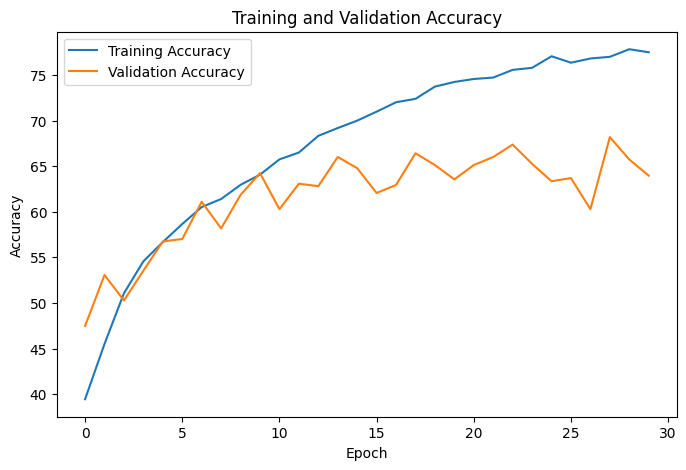

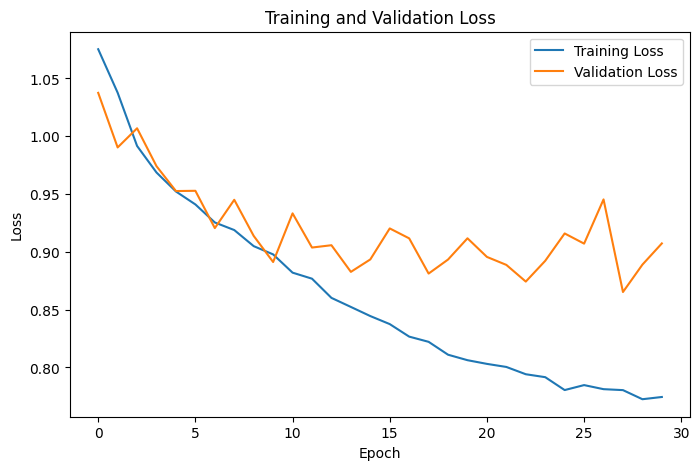

In [51]:
#Training,Validation and Test Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy_lstm_improved, label='Training Accuracy')
plt.plot(validation_accuracy_lstm_improved, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Training,Validation and Test Loss graph
plt.figure(figsize=(8, 5))
plt.plot(train_loss_lstm_improved, label='Training Loss')
plt.plot(validation_loss_lstm_improved, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [52]:
# Test phase
model_improved.eval()
correct_test_length_lstm_improved = 0
total_test_lstm_improved = 0
y_true_lstm_improved = []
y_pred_lstm_improved = []

# test_loss = []
test_accuracy_lstm_improved =[]
test_total_loss_lstm_improved = 0.0
predicted_list_lstm_improved = []


with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    outputs = model_improved(inputs)

    labels = labels.view(-1)
    test_total_loss_lstm_improved += loss_function_lstm_improved(outputs, labels).item()

    _, predicted_lstm_improved = torch.max(outputs, 1)
    predicted_test_probs = torch.softmax(outputs, dim=1)

    total_test_lstm_improved += labels.size(0)
    correct_test_length_lstm_improved += (predicted_lstm_improved == labels).sum().item()

    y_true_lstm_improved.extend(labels.cpu().numpy())
    y_pred_lstm_improved.extend(predicted_lstm_improved.cpu().numpy())
    predicted_list_lstm_improved.extend(predicted_test_probs.cpu().numpy())


y_pred_lstm_improved = np.array(y_pred_lstm_improved)
y_true_lstm_improved = np.array(y_true_lstm_improved)
predicted_list_lstm_improved = np.array(predicted_list_lstm_improved)

test_accuracy_lstm_improved = 100 * (correct_test_length_lstm_improved / total_test_lstm_improved)
print(f"Test Accuracy: {test_accuracy_lstm_improved:.2f}%")

#precision, recall, F1 score
precision, recall, f1, _ = precision_recall_fscore_support(y_true_lstm_improved, y_pred_lstm_improved, average='weighted')
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

test_loss_lstm_improved = test_total_loss_lstm_improved /len(test_loader)

test_accuracies_plot_lstm_improved = [test_accuracy_lstm_improved] * epochs
test_loss_plot_lstm_improved = [test_loss_lstm_improved] * epochs

Test Accuracy: 64.53%
Precision: 0.6747, Recall: 0.6453, F1: 0.6568


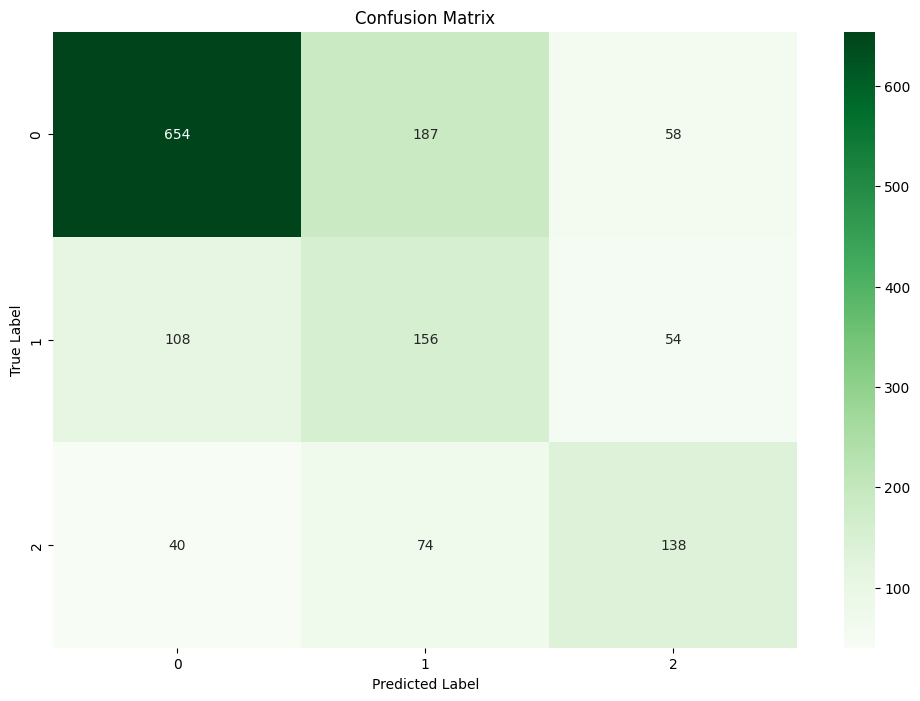

In [53]:
#Confusion Matrix
conf_matrix = confusion_matrix(y_true_lstm_improved, y_pred_lstm_improved)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

4. Directly compare the performance of your improved model to the baseline model

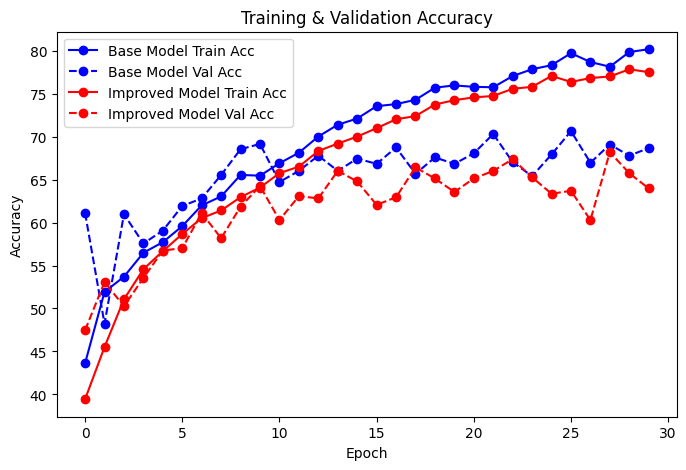

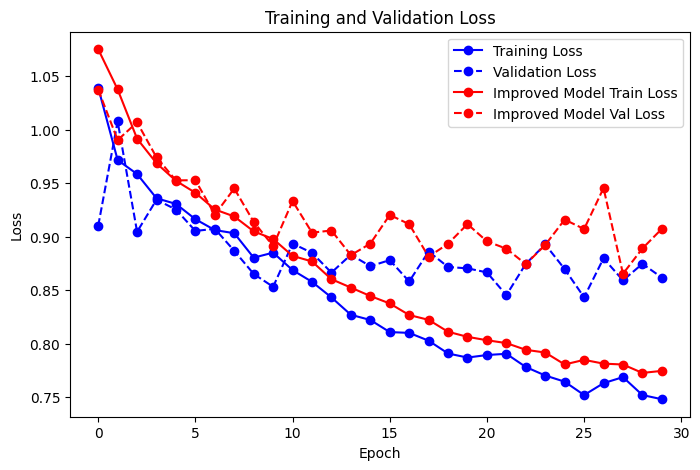

In [54]:
### ADD YOUR CODE HERE ###

#Training,Validation Accuracy graph

plt.figure(figsize=(8, 5))
plt.plot(train_accuracy_lstm, 'bo-', label="Base Model Train Acc")
plt.plot(validation_accuracy_lstm, 'b--o', label='Base Model Val Acc')
plt.plot(train_accuracy_lstm_improved, 'ro-', label="Improved Model Train Acc")
plt.plot(validation_accuracy_lstm_improved, 'r--o',  label='Improved Model Val Acc')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Training,Validation and Test Loss graph
plt.figure(figsize=(8, 5))
plt.plot(train_loss_lstm, 'bo-', label='Training Loss')
plt.plot(validation_loss_lstm, 'b--o', label='Validation Loss')
plt.plot(train_loss_lstm_improved, 'ro-',  label="Improved Model Train Loss")
plt.plot(validation_loss_lstm_improved, 'r--o',  label='Improved Model Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

<span style='color:green'>### YOUR ANSWER ###</span>

Analysis of Base Model and Improved Model:

In our updated model we update the LSTM layers with GRU and use bidirectional=True. We also use the Glove pre-trained word embeddings. Based on the comparsion graphs for accuracy we can see that the the training values are increasing steadily at a controlled rate. And here for the improved model the validation curve is slightly more stable compared to the base model.  There is still the fluctuations in the validation values but there is also more stablitity which shows more generalizing. The training loss is decreasing too steadily and lesser number of spikes in the validation loss in the improved mode. This shows there is lesser overftiing compared to base nodel and also shows that the additions of bidirectional and glvoe embeddings has helped it learn better.

However we can see that the test accruacy has reduced, but we can say that even though the acccuarcy is reduced there is lesser memorizing happening which is benifical in the learning and the classifciation of data. Now we cna see that the precision, recall and f1-score values have reduced but further hypertunning and methods of augementation can help the performance increase and prevent overfitting as well.

Main points we can consider here is that GRU is better at generalizing than LSTM. As the metics shows lesser overffing in the improved model. Even though the accruacy was not as upto the mark as compaerd to LSTM base model at 70.39%. Now here glove and bidirectional did not benifit as much compare to adding more layers of GRU, since Glove is not necessarily matching the dataset vocab, so proably a better domain specific embedding might help with the trianing in that aspect. And adding the bidirectional parameter only seemed to have increased the training time each epoch since it does both forward and backward computaion and hence increasing the time.

Now overall the improved model with GRU layers is a better model as it has lesser overfitting happening and more clearer generalizing with the training/validation performance to be more stable. So further hyperparameter training and regularization can help improve even the accuarcy with lesser overfitting. 

In the end even though accuracy is important, the model generalizing without overrfitting is the best model. So even with less accuracy the improved model performance is better than the base model as it generalizing much correctly based on the dataset and the same preprocessing steps as base model.


5. Save the weights of the trained neural network

In [55]:
### ADD YOUR CODE HERE ###
if best_model_weight_lstm_improved is not None:
  torch.save(best_model_weight_lstm_improved, 'lstm_base_model_improved.pt')


## Step 4: Discussion

1. Briefly describe the dataset and its key characteristics

<span style='color:green'>### YOUR ANSWER ###</span>

Here the dataset we have chosen is dealing with data for ailine sentiments and reviews. It has data such as tweets made by customers who have travellled by differnt airlines. It gives opinions from the travellers in three main categories postive, neurtal and negaitve. Main attributes of the data are the text with reviews, sentiment attribute belonging to the one category, and other values realted to the sentiment. The data is highly sampled with data for the negative sentiment catgeory compared to the other two classes. The reviews/opinions in the text atttribute would benifit is there is a word embedding that is more domian specific to this data so it can help with better preprocessing.
This is a very typical dataset that is used for sentiment analysis.


2. Describe both your baseline and improved LSTM architectures in detail

<span style='color:green'>### YOUR ANSWER ###</span>

Base Model Architecture:

This is a model with LSTM layers with these aspects of the architecture:
- Embedding layer: used to convert into dense layers that ussing the word embeddings
- the layer takes two parameters, the word token which is mapped to a numerical sequence to create the dense vector representation and then it takes also the vocab size.
- LSTM Layers: Has 3 layers each takes paramters input zie, hidden units, and dropout value.
- Last it has the fully connected layer that maps to the 3 output classes using softmax activation fucntion. Softmax helps with multiclassification into the three categories.

Improved Model Architecture:

Here it uses the base model as the base and then changeing the parameters used and adding additional layers:
- Change the LSTM to GRU layer. And adding two more GRU layers
- Glove Pre-trained Embedding: Changing the embedding used to Glove's pre-trained word embeddings using the Vocab function of torchtext and using the freeze parameter so that it is not fine tunning during the training to see the effects. And if not using it actually affects the training and decreases the accuracy further.
- Bideirectional Set: This parameter is set to True in the GRU layers to process the sequence both forward and backward hence allowing to learn and gather more information from the tokens in the sentences.
- Full connectedlayer as base model.
- Softmax activation
  

3. Discuss the results, comparing the performance of the baseline and improved models

<span style='color:green'>### YOUR ANSWER ###</span>

Base & Improved Model Metrics
![LSTM_base_improved](LSTM_base_improved.png) 

As we can see in our graphs above the improved accruacy curves are slightly more stable/smoother compared to the base model. Training values are higher in both base and improved. Hoever when considering the validation accuracy of the models we can tell that the base has more fluctuations compared to the improved model which shows that there might be more overfitting happening in  the base model. Even though there are spikes in the improved model it still is much lesser and remains more consistent and so shows its performs much better.

Similarly the loss values of base and improved the performance is much stable in the improved model. In the improved model the training loss is slightly higer that tells that the model is not memorizing immeditialy and is taking its time to learn and generalize compared to base model even though lower value it has a lot more up and down spikes and hence showing that improved model learns better and has lesser overfitting.

Test Accuracy and Metrics

Base Model ![Test_accuarcy_Base_lstm](Test_accuracy_base_lstm.png)       

Improved Model ![Test_accuarcy_improved_lstm](Test_accuracy_improved_lstm.png) 

Now when comparing the test accuracy we can see a significant decrease in the values for the improved model but that shows how the improved model is learning much better and not memorizing the data unlike in the base model which can sugest potential overfititng and thus the high accruacy is misleading value which needs more in-depth review or hypertunning.

Overall even though low accuracy the improved model performaces better in terms of the training/validaiton metrics.

4. Discuss the strengths and limitations of using recurrent neural models for sentiment analysis

<span style='color:green'>### YOUR ANSWER ###</span>

Strengths:
- Unlike the traditional vanilla RNN's, LSTM are better useful in processing long sequences of text. It can capture more data and informattion whihc makes it benifical for sentiment/NLP tasks. This is seen oh how the words are tokenized and used in the LSTM model.
- Helps avoid vanishing gradient problem. In the LSTM layers it uses the gates like forget gate which allows the control if information and gradients in the network so it prevents gradients from becoming to small during training.
- Handles variable lengths of sequences by dynamically adjusting the internal state.
- Better are generalizing than RNN's since LSTM allows to better learn the patterns across the dataset.

Limitations:
- Computational complexity than other neural networks. LSTM's require more time training and resources based on the dataset and size and layers defined.
- Much more sucsceptible to overfitting when there is insufficinet data and this is true based on our dataset chosen. Regurlaization can help mitigate the issue.
- Lot more time with hypertunning required. Lot of differrent values  need to be tried and finding the right ones takes a lot more combinations and is time consuming.
- Due to long hyperparameter tuning more time to train too. If the dataset is bigger it can take way more time training.

However LSTM is used in various NLP task and seems to solve challenges such as speech recogniaion timer series forecasting becuase of the sequential pattern used in the model.



5. References. Include details on all the resources used to complete this part.

<span style='color:green'>### YOUR ANSWER ###</span>

Dataset:
- Airline Sentiment Twitter Tweets Data:  https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment/data

Understand the setup for sentiment analysis:
- https://medium.com/@robdelacruz/sentiment-analysis-using-natural-language-processing-nlp-3c12b77a73ec#:~:text=Sentiment%20analysis%20is%20a%20technique,across%20numerous%20industries%20and%20applications.

Using the tokenizers and other preprocess steps:
- https://javilopezcastillo.medium.com/sentiment-analysis-using-lstm-networks-a-deep-dive-into-textual-data-61cdd2e43dec
- https://www.analyticsvidhya.com/blog/2022/01/sentiment-analysis-with-lstm/
- https://medium.com/@pingsubhak/handling-missing-values-in-dataset-7-methods-that-you-need-to-know-5067d4e32b62
- https://datastud.dev/posts/nlp-preprocess
- https://www.nltk.org/api/nltk.tokenize.punkt.html
- 

Word Cloud Usage and Visuals using NLTK:
- https://www.geeksforgeeks.org/generating-word-cloud-python/
- https://dariuslfuller.medium.com/creating-visuals-with-nltks-freqdist-ac4e667e49f3

Embedding pre-processing and Padding methods:
- https://csci4050u.science.ontariotechu.ca/part-5/2-text-processing.html
- https://pytorch.org/text/stable/vocab.html
- https://pytorch.org/docs/stable/generated/torch.nn.utils.rnn.pad_sequence.html
- https://www.geeksforgeeks.org/how-do-you-handle-sequence-padding-and-packing-in-pytorch-for-rnns/
- https://www.kaggle.com/code/imabhilash/pytorch-classifier-lstm-and-embeddings

LSTM references:
- https://www.geeksforgeeks.org/long-short-term-memory-networks-using-pytorch/
- https://cnvrg.io/pytorch-lstm/
- https://machinelearningmastery.com/lstm-for-time-series-prediction-in-pytorch/
- https://github.com/ritchieng/deep-learning-wizard/blob/master/docs/deep_learning/practical_pytorch/pytorch_lstm_neuralnetwork.md

Glove usage references:
- https://medium.com/analytics-vidhya/word2vec-glove-fasttext-and-baseline-word-embeddings-step-by-step-d0489c15d10b
- https://github.com/deependujha/Word-Embedding-PyTorch
- https://github.com/stanfordnlp/GloVe
- https://medium.com/@skillcate/sentiment-classification-using-neural-networks-a-complete-guide-1798aaf357cd

LSTM with Bidirectional and Attention:
- https://www.kaggle.com/code/khalildmk/simple-two-layer-bidirectional-lstm-with-pytorch
- https://www.kaggle.com/code/dannykliu/lstm-with-attention-clr-in-pytorch

LSTM adavantages/disadvantages:
- https://medium.com/@prudhviraju.srivatsavaya/lstm-implementation-advantages-and-diadvantages-914a96fa0acb

Contribution:


| Team Member | Assignment Part | Contribution (%) |
|---|---|-------------|
| Himanshu Singh   | Part 4         | 30%                | 
| Rebecca Abraham  | Part 4         | 70%                |